Import Libraries

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

Load data

In [ ]:
df = pd.read_csv('food_messy_dataset1.csv')

Data Cleaning

Convert messy string columns to numeric (coerce errors to NaN)

In [ ]:
cols_to_fix = ['num_items', 'delivery_rating', 'customer_age']
for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')

Drop rows where target variable is missing

In [ ]:
df = df.dropna(subset=['total_bill'])

Remove extreme outliers in the target variable

In [ ]:
df = df[df['total_bill'] < df['total_bill'].quantile(0.95)]

Imputation (Filling missing values)

Fill numeric columns with median

In [ ]:
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

Fill categorical columns with mode

In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

Feature Engineering

Drop non-predictive unique identifiers

In [ ]:
df = df.drop(columns=['order_id', 'restaurant_name'])

One-Hot Encoding for categorical variables

In [ ]:
df = pd.get_dummies(df, columns=['cuisine_type', 'meal_time', 'customer_gender', 'weekend'], drop_first=True)

Feature/Target Split (X/Y)

In [ ]:
X = df.drop('total_bill', axis=1)
y = df['total_bill']

Scaling (Standardization: (x - mean) / std)

In [ ]:
X_mean = X.mean()
X_std = X.std()
X_scaled = (X - X_mean) / X_std

Train/Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

Model Training

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Evaluation

In [ ]:
predictions = model.predict(X_test)
print(f"R² Score: {r2_score(y_test, predictions):.4f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, predictions):.2f}")

R² Score: 0.9253
Mean Absolute Error: 71.69


/tmp/ipykernel_1753/1596308468.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coeffs, x='Coefficient', y='Feature', palette='magma')


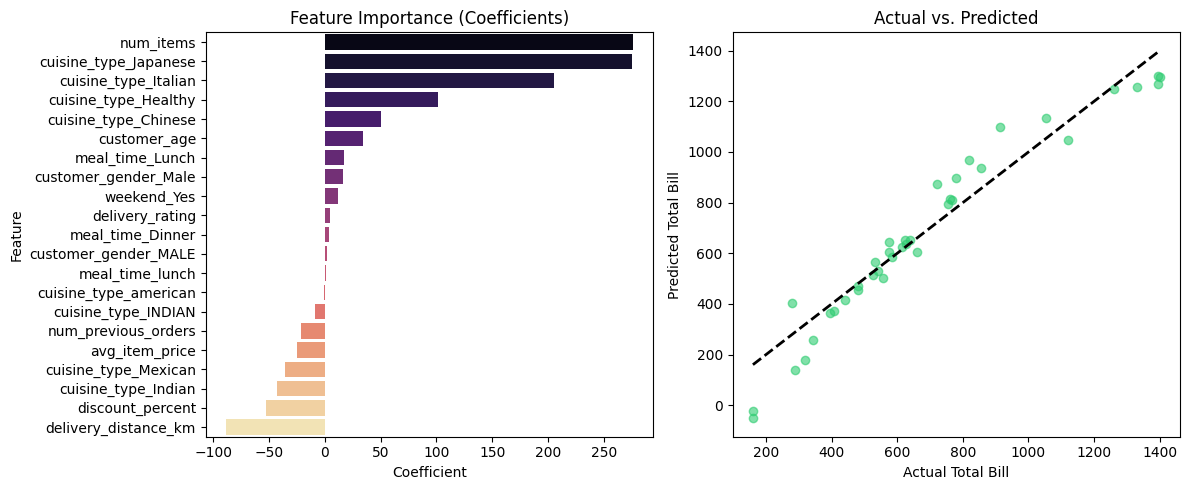

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract and Sort Coefficients
coeffs = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

# 2. Visualizing Results
plt.figure(figsize=(12, 5))

# Subplot 1: Feature Importance
plt.subplot(1, 2, 1)
sns.barplot(data=coeffs, x='Coefficient', y='Feature', palette='magma')
plt.title('Feature Importance (Coefficients)')

# Subplot 2: Actual vs Predicted
plt.subplot(1, 2, 2)
plt.scatter(y_test, predictions, alpha=0.6, color='#2ecc71')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Total Bill')
plt.ylabel('Predicted Total Bill')
plt.title('Actual vs. Predicted')

plt.tight_layout()
plt.savefig('model_evaluation.png')

Download Model

In [ ]:
import pickle
from google.colab import files

df_raw = pd.read_csv('food_messy_dataset1.csv')
cat_cols = ['cuisine_type', 'meal_time', 'customer_gender', 'weekend']

model_artifacts = {
    'model': model,
    'columns': X.columns,
    'mean': X_mean,
    'std': X_std,
    'categorical_options': {
        col: sorted(df_raw[col].dropna().unique().tolist()) for col in cat_cols
    }
}

# 3. Save and Download
with open('model_data.pkl', 'wb') as f:
    pickle.dump(model_artifacts, f)

files.download('model_data.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>